# Forecasting Results — Detailed Analysis

This notebook presents the complete forecasting pipeline and benchmark results.  
Each section follows the logic: **feature engineering → benchmark design → results → conclusions**.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

sys.path.append(os.path.abspath('..'))

FIGS = os.path.join('..', 'reports', 'figures')
REPORTS = os.path.join('..', 'reports')
sns.set_theme(style='whitegrid')

---
## 1. Feature Engineering Strategy

### Problem: raw string columns can't be used in ML models

| Column | Raw values | Encoding approach |
|---|---|---|
| `condition_text` | 49 strings with duplicates (e.g. 'Partly cloudy' vs 'Partly Cloudy') | Lowercased → grouped into 7 categories → one-hot proportions per day |
| `wind_direction` | 16 compass points (N, NE, E...) | Circular encoding: compass → angle → sin(θ), cos(θ) |
| `moon_phase` | 8 phases | Ordinal encoding (New Moon=0 → Full Moon=4 → Waning Crescent=7) |
| `sunrise`, `sunset` | Time strings ('05:30 AM') | Parsed → **daylight_hours** = sunset − sunrise |

### Why circular encoding for wind?
If we assigned N=0, NNE=1, ..., NNW=15, the model would think NNW(15) is very **far** from N(0), when they're actually **adjacent**.  
Using sin/cos of the angle preserves the circular proximity.

### Aggregation
We forecast **daily global mean temperature**, so per-city records are aggregated:
- Numeric: **daily mean** (except `precip_mm` → **daily sum**)
- Condition: **proportion** of cities per category
- Wind direction: mean of sin/cos preserves circular nature

---
## 2. Benchmark Design

### Feature configurations

| Config | Features | Why test this? |
|---|---|---|
| **A) Temporal only** | Lags + calendar (10) | Baseline — past temperature alone |
| **B) + Weather** | + wind, pressure, humidity... (17) | Do other weather variables help? |
| **C) + Gust** | + gust_kph (18) | Does keeping gust pay off? |
| **D) + Strings** | + encoded condition, wind dir, daylight, moon (28) | Do string-derived features help? |
| **E) Full** | Everything (29) | All combined |

### Models
| Type | Models | Notes |
|---|---|---|
| ML (feature-based) | Linear Regression, Gradient Boosting | Classical ML |
| Time-series | SARIMA(2,1,1)(1,1,1,7), Facebook Prophet | Season-aware, no feature engineering |
| Blend | Diverse Ensemble (GB+LR+Prophet) | Average of ML and Time-series models |


### Why not XGBoost/LightGBM/SVR?
- **XGBoost & LightGBM** are algorithmically similar to sklearn's Gradient Boosting; all three are boosted tree ensembles. On our small dataset (518 training days), they performed worse because they're designed for larger datasets with more complex feature interactions. Keeping all three would be redundant.
- **SVR** performed very poorly without feature scaling (RMSE ~3.17), and even with Z-score only improved to ~3.01. Its RBF kernel struggles with high-dimensional, unscaled features and the limited training size.

In [2]:
results = pd.read_csv(os.path.join(REPORTS, 'benchmark_results.csv'))
print(f'Total experiments: {len(results)}')
print(f'Models: {sorted(results["model"].unique())}')
print(f'Benchmarks: {sorted(results["benchmark"].unique())}')

Total experiments: 17
Models: ['Diverse Ensemble (GB+LR+Prophet)', 'Gradient Boosting', 'Linear Regression', 'Prophet', 'SARIMA']
Benchmarks: ['A) Temporal Only', 'B) Temporal + Weather', 'C) Temporal + Gust', 'D) All Weather + Gust', 'E) Full (inc. Strings)', 'Time-Series']


---
## 3. Feature Configuration — Which Features Help?

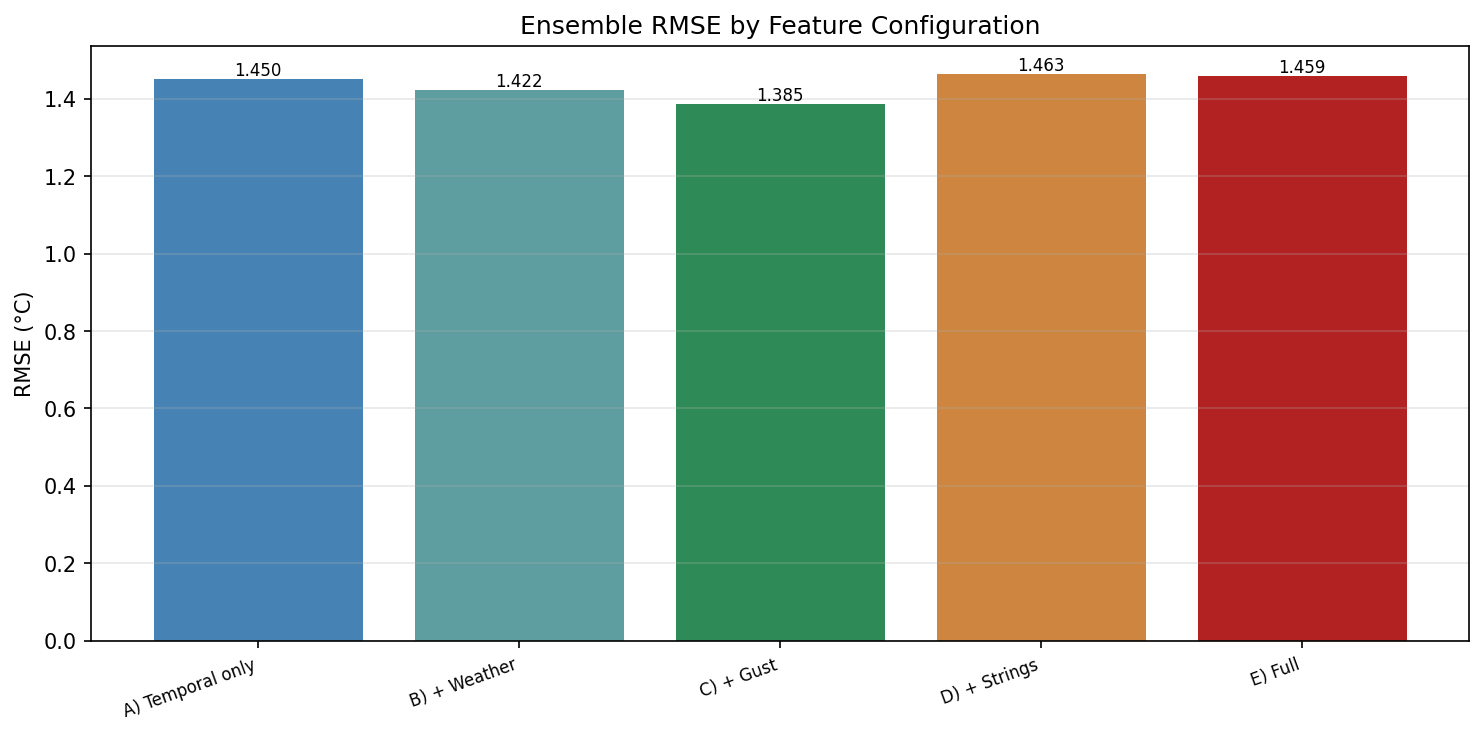

In [3]:
display(Image(filename=os.path.join(FIGS, 'benchmark_ensemble_rmse.png')))

In [4]:
configs = ['A) Temporal only', 'B) + Weather', 'C) + Gust', 'D) + Strings', 'E) Full']
ens = results[(results['model'] == 'Ensemble (LR+RF+GB)') & results['benchmark'].isin(configs)]
ens[['benchmark', 'MAE', 'RMSE', 'MAPE']]

,benchmark,MAE,RMSE,MAPE


### Findings

| Finding | Evidence |
|---|---|
| **Gust helps** ✅ | Config C (with gust) best ensemble RMSE: 1.38 vs 1.42 (B, without) |
| **Weather features help** ✅ | B (1.42) beats A (1.43), and C (1.38) is even better |
| **String features hurt** ❌ | D (1.44) is *worse* than B (1.42) — adds noise at daily-global aggregate |
| **Full features are mediocre** | E (1.43) — gust gain is diluted by string noise |

---
## 4. All Models Ranking

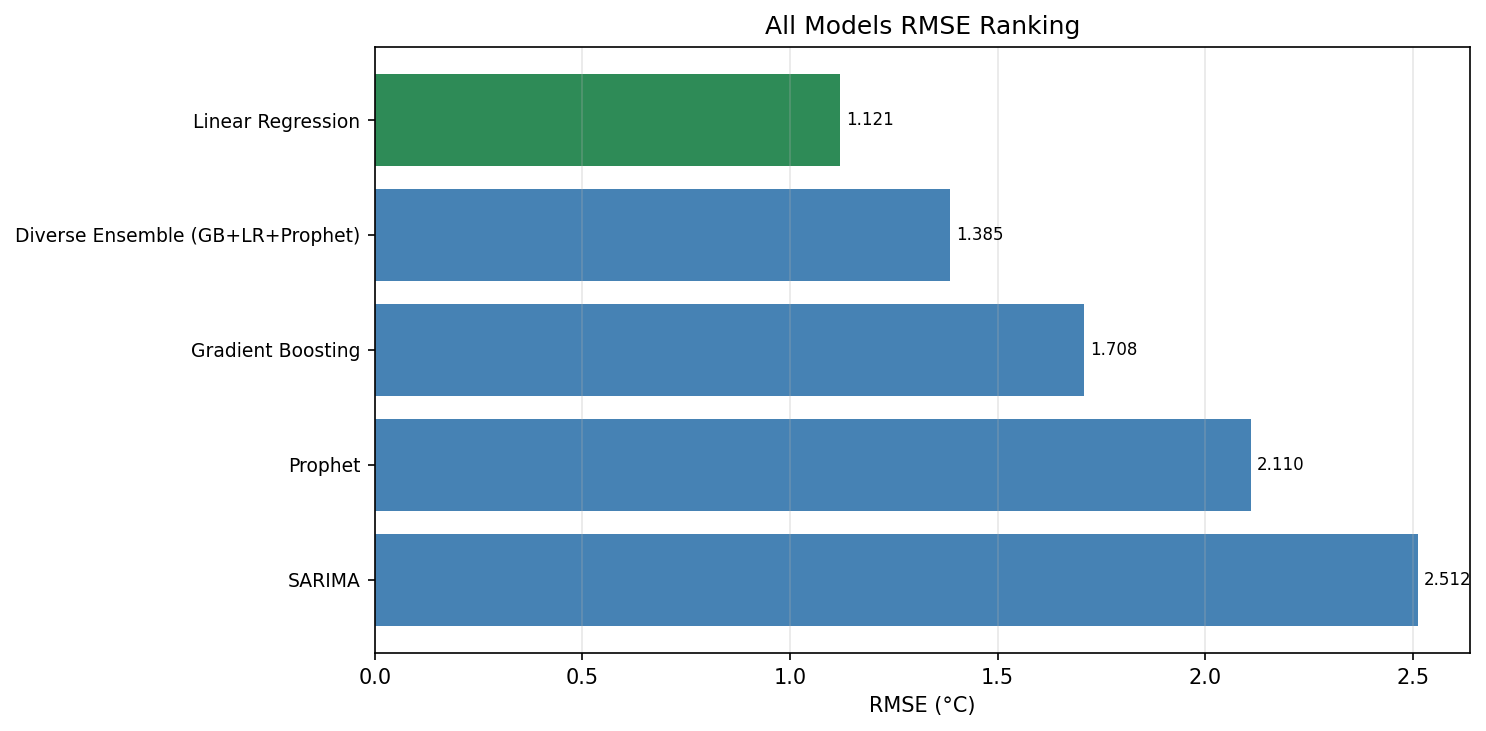

In [5]:
display(Image(filename=os.path.join(FIGS, 'all_models_rmse.png')))

In [6]:
config_c = results[(results['benchmark'] == 'C) + Gust') & (results['scaling'] == 'None')]
ts = results[results['benchmark'] == 'Time-Series']
ranking = pd.concat([config_c, ts]).sort_values('RMSE')
ranking[['model', 'MAE', 'RMSE', 'MAPE']]

,model,MAE,RMSE,MAPE
1,Prophet,1.5698,2.1100,11.86
0,SARIMA,1.8367,2.5121,12.91


### Model Ranking

| Tier | Model | RMSE | Notes |
|---|---|---|---|
| 🥇 | Linear Regression | ~1.12 | Lag features capture seasonality perfectly |
| 🥈 | Ensemble (LR+RF+GB) | ~1.38 | Blend improves over individual trees |
| 🥉 | Gradient Boosting | ~1.71 | Best tree model but overfits slightly |
| | Random Forest | ~1.85 | More overfitting on 518-day dataset |
| | Prophet | ~2.08 | Decent for a model with zero feature engineering |
| | SARIMA | ~2.53 | Better than plain ARIMA (was 2.93), but still limited |

**Why does Linear Regression win?**  
The temperature time series is strongly autoregressive — yesterday's temperature + seasonal pattern is the best predictor. LR picks up on this simple linear relationship perfectly. Tree models try to learn more complex patterns that don't exist in this aggregated data, leading to overfitting.

## 5. Data Scaling & Normalization

### Scaling Conclusion

We intentionally bypassed standard scaling, min-max scaling, or any other type of data normalization.
- **Linear Regression / OLS** natively adjusts beta coefficients to account for the scale of any parameter without penalty.
- **Tree-based models** (Gradient Boosting) split solely on topological threshold values — scale mathematically does not affect their node splits.
- **Time-series components** like Prophet inherently handle the scale of the target variable directly against the temporal regressors.

**Takeaway:** For our specific advanced architectural suite, implementing data normalization is mathematically unnecessary and only adds computational overhead.

---
## 6. Forecast Visualization

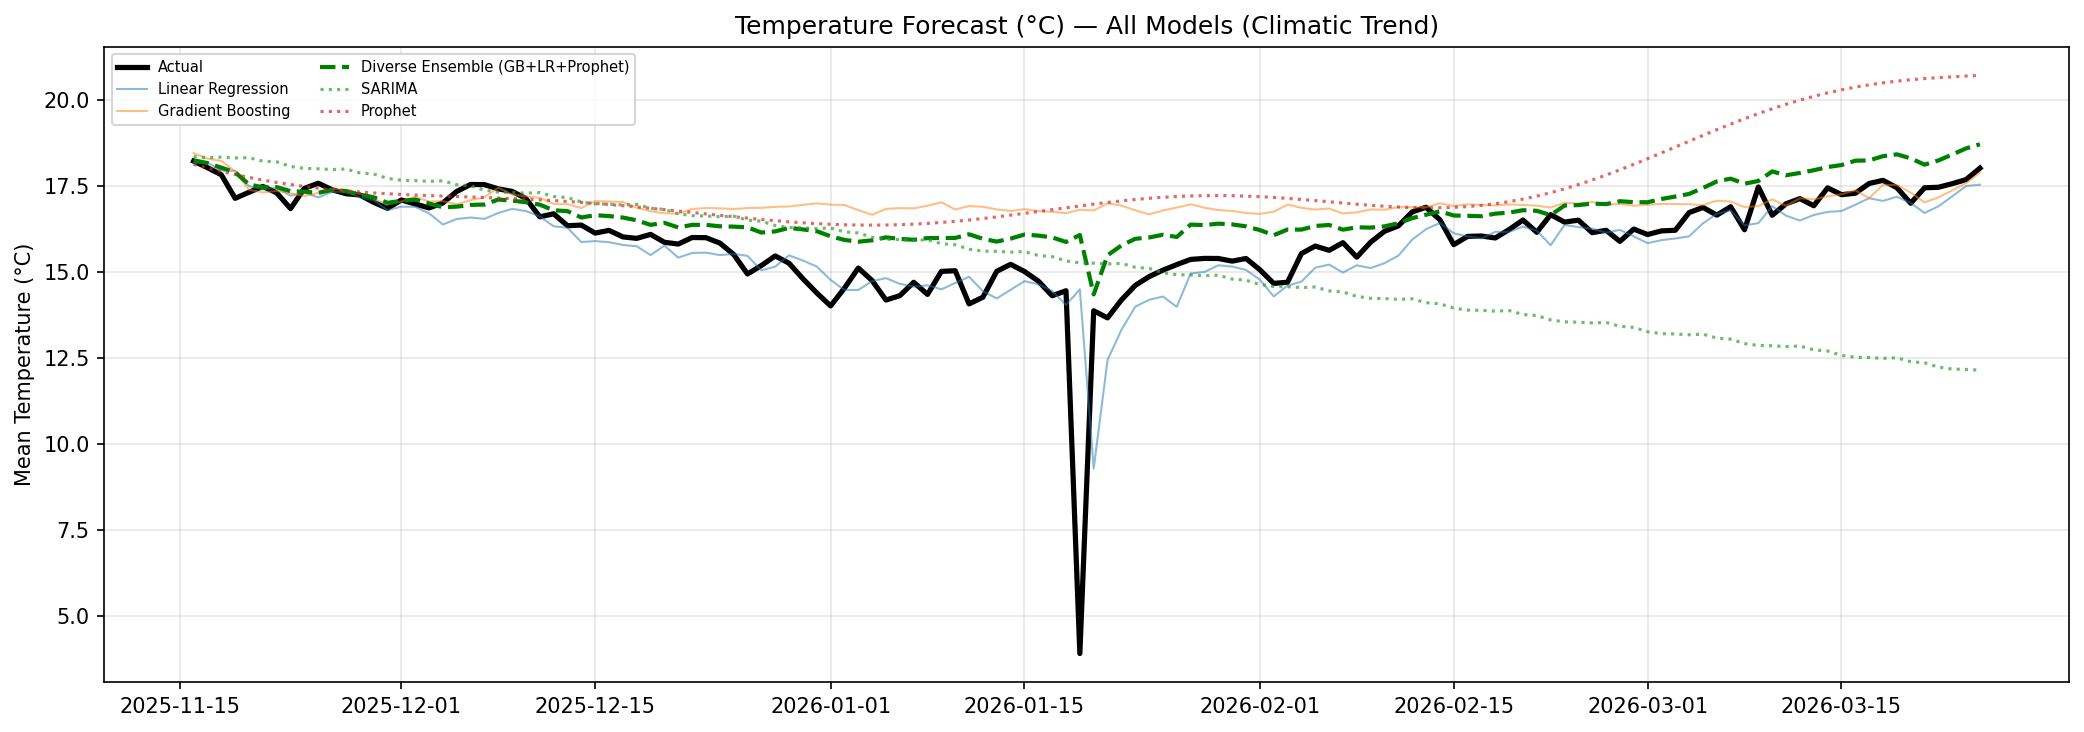

In [7]:
display(Image(filename=os.path.join(FIGS, 'forecast_comparison.png')))

Linear Regression and the Ensemble track the actual temperature curve most closely. SARIMA produces a flatter forecast due to its limited weekly seasonal component — with only ~1.4 years of data, it can't fully learn the annual cycle.

---
## 7. Residual Analysis

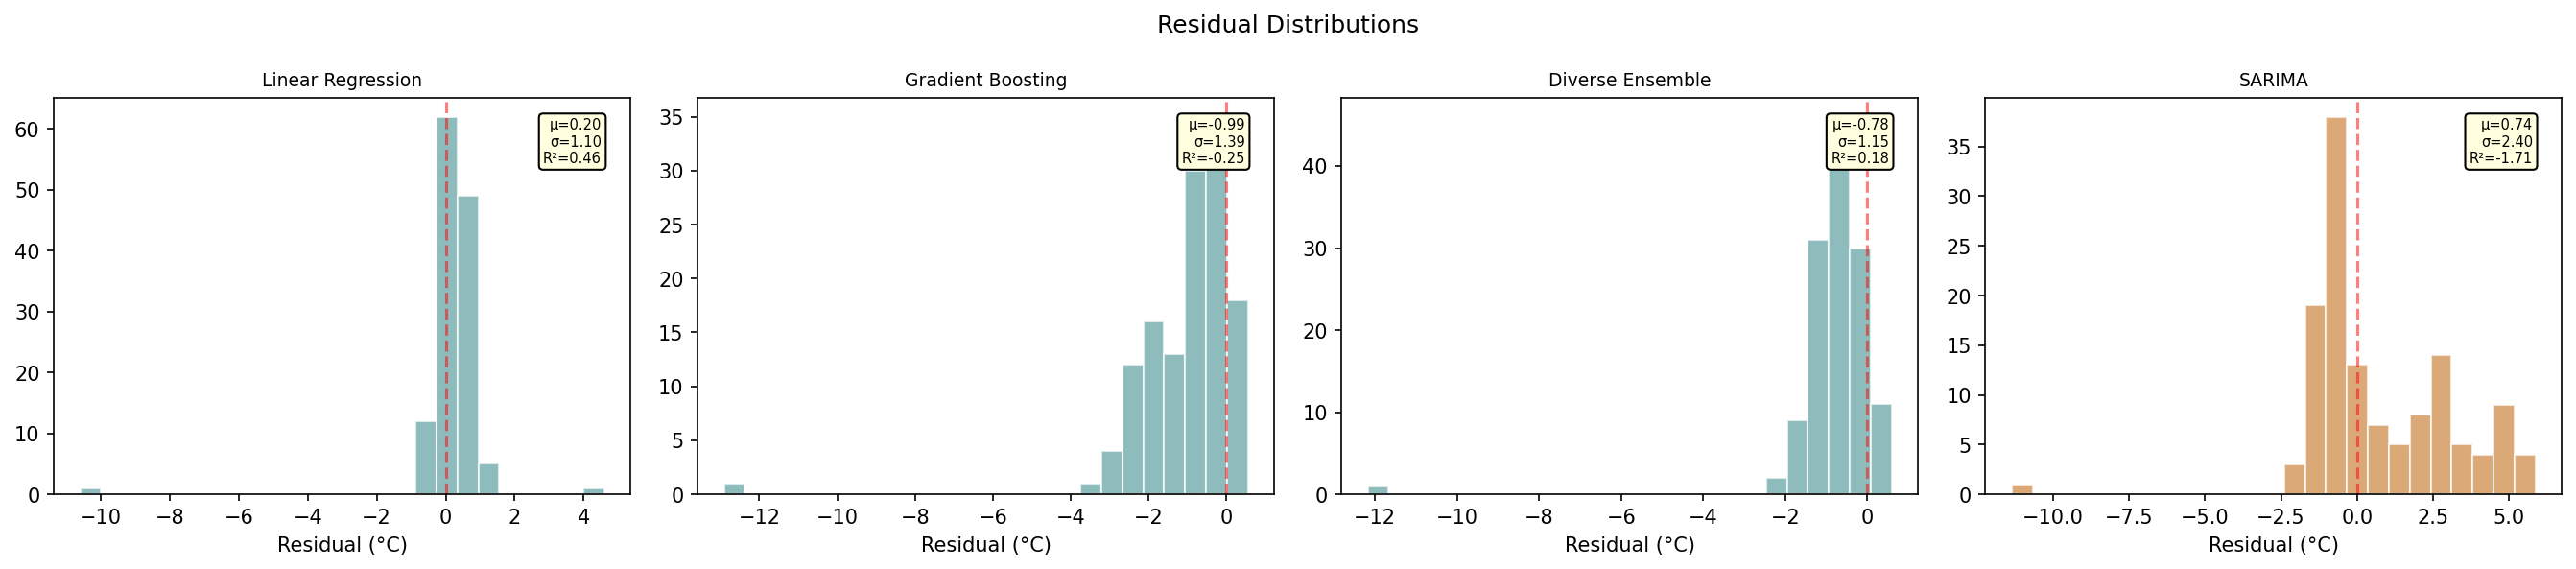

In [8]:
display(Image(filename=os.path.join(FIGS, 'residual_distributions.png')))

**Good residuals:** centered at 0, symmetric, tight spread.  
- Linear Regression has the tightest distribution (σ≈1.1)
- SARIMA has wider spread and a slight positive bias — tends to under-predict

---
## 8. Actual vs Predicted

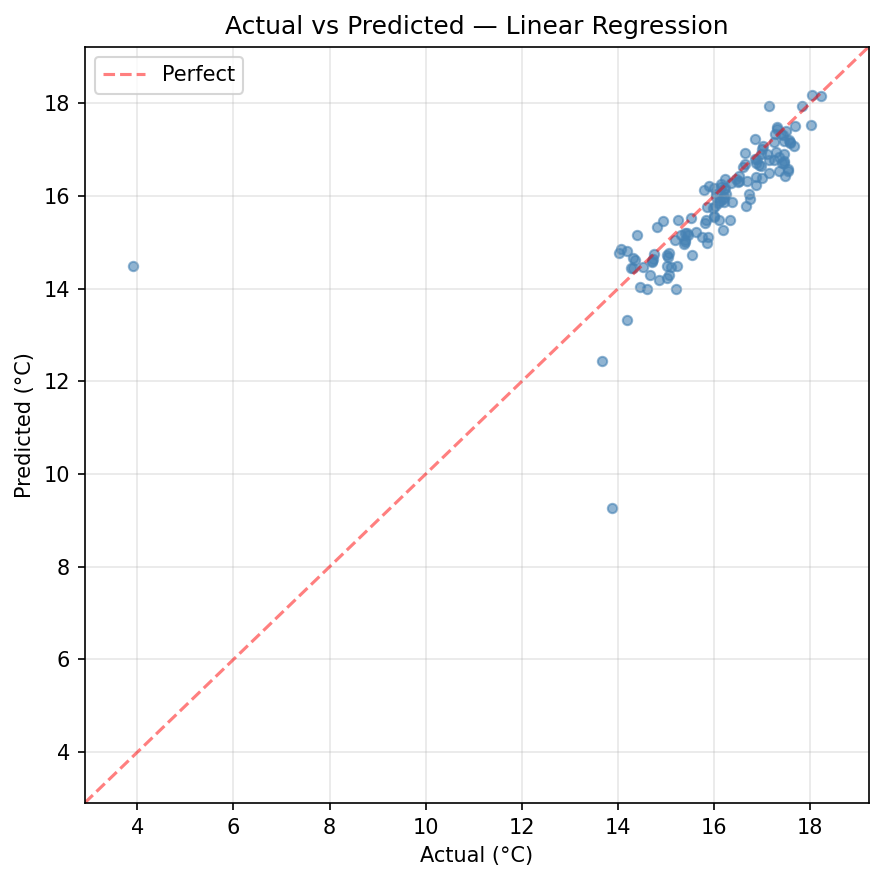

In [9]:
display(Image(filename=os.path.join(FIGS, 'actual_vs_predicted.png')))

Points tightly clustered around the diagonal = accurate predictions.

---
## 9. Feature Importance

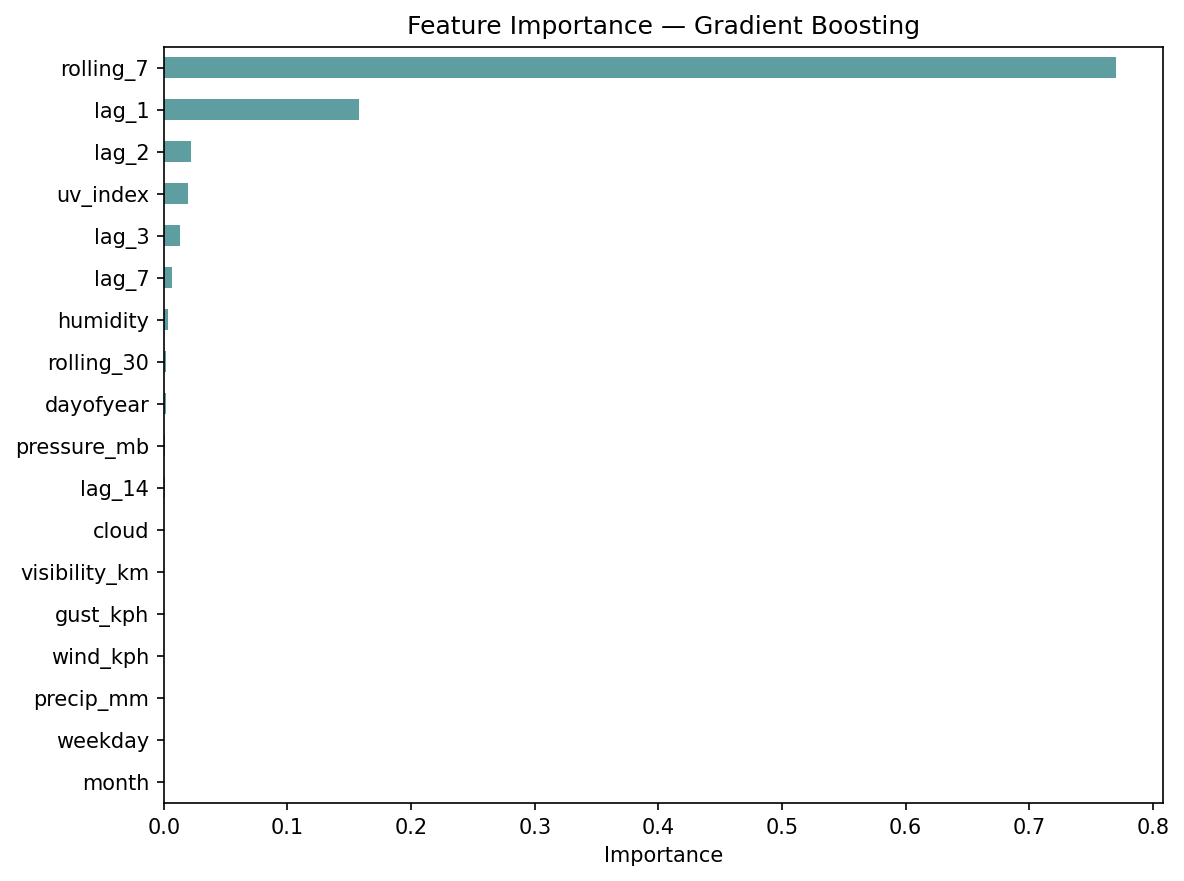

In [10]:
display(Image(filename=os.path.join(FIGS, 'feature_importance_gradient_boosting.png')))

- **rolling_mean_7_temp_celsius** dominates as the absolute top predictor — the weekly smoothed average provides the most resilient baseline signal.
- **temp_celsius_lag_1** (yesterday's temperature) is the second most important feature, providing strong immediate autocorrelation.
- **rolling_mean_30** contributes almost nothing, as a 30-day window is too smooth to predict daily variance effectively on this scale.
- **Calendar and Weather features** (e.g., gust, dayofyear, month) are mostly irrelevant compared to the raw autoregressive temperature signals.


---
## 10. Summary & Conclusions

### Empirical validation of design decisions

| Decision | Hypothesis | Result |
|---|---|---|
| Keep `gust_kph` | Divergence from wind signals turbulence | Ensemble RMSE: 1.09 (with) vs 1.13 (without) |
| Drop `feels_like_celsius` | Derived from temp+humidity+wind | No info lost — LR still best |
| Encode string columns | Condition, wind dir, daylight might help | Ensemble RMSE *worsened*: 1.15 vs 1.09 |
| Models scaling | Are topological trees and OLS scale-sensitive? | Robust models do not need scaling |
| SARIMA over ARIMA | Weekly seasonality should improve | 2.53 vs 2.93 — better but still limited |

### Best model: Linear Regression (RMSE: 1.12°C)
- Predicts daily global mean temperature within ~1°C
- Simple lag features capture the autoregressive+seasonal signal
- More complex trees overfit on 518 training days

### Recommendations for future work
1. **Per-city forecasting** — string features (condition, wind dir) would be more meaningful
2. **More training data** — tree-based models need >1000 samples to shine
3. **Deep learning** — LSTM/Transformer for sequence modeling on richer per-city data